# Practical 6: Sentence Embeddings & Semantic Search

1. **Encode 20 sentences with SBERT** (`all-MiniLM-L6-v2`), compute
   pairwise cosine similarity, and find the best match for a query.
2. **Visualize the embeddings with t-SNE**, grouped by topic, and check
   whether meaningful clusters actually form.


### Install the dependencies

In [4]:
# sentence-transformers -> SBERT models (loads all-MiniLM-L6-v2, ~80MB, on first run)
# scikit-learn            -> t-SNE for the 2D projection
# matplotlib               -> plotting
# !pip install -q sentence-transformers scikit-learn matplotlib

In [1]:
import sys, os
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from utils.config import config
print("Model:", config.model_name)
print("Random seed:", config.random_seed)
print("t-SNE perplexity:", config.tsne_perplexity)


Model: all-MiniLM-L6-v2
Random seed: 42
t-SNE perplexity: 5


## Encode sentences & find the best match

### The dataset
20 sentences across 4 topics (5 each): **Sports**, **Technology**, **Food & Cooking**, **Travel & Places**

In [2]:
from src.data import get_sentences, get_topics

sentences = get_sentences()
topics = get_topics()

for sentence, topic in zip(sentences, topics):
    print(f"[{topic:15}] {sentence}")

[Sports         ] The striker scored a stunning goal in the final minute.
[Sports         ] She trains every morning to prepare for the marathon.
[Sports         ] The home team won the championship after a tense overtime.
[Sports         ] His serve was clocked at over 200 kilometers per hour.
[Sports         ] The coach called a timeout to reset the team's strategy.
[Technology     ] The new smartphone features a faster processor and better camera.
[Technology     ] Developers are increasingly using AI to write and review code.
[Technology     ] The startup raised funding to build its cloud infrastructure.
[Technology     ] A software update fixed the security vulnerability overnight.
[Technology     ] The company unveiled a robot capable of folding laundry.
[Food & Cooking ] She simmered the tomato sauce for hours to deepen the flavor.
[Food & Cooking ] The bakery's sourdough loaf sells out within an hour of opening.
[Food & Cooking ] He seasoned the steak generously before searing 

### Encode all 20 sentences with SBERT

In [3]:
from src.embedder import encode_sentences

embeddings = encode_sentences(sentences)
print(f"Embeddings shape: {embeddings.shape}")  # (20, 384) for all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embeddings shape: (20, 384)


### Pairwise cosine similarity

Computes similarity between every pair of the 20 sentences at once, then
visualizes it as a heatmap — sentences from the SAME topic should show up
as brighter squares clustered along the diagonal blocks.

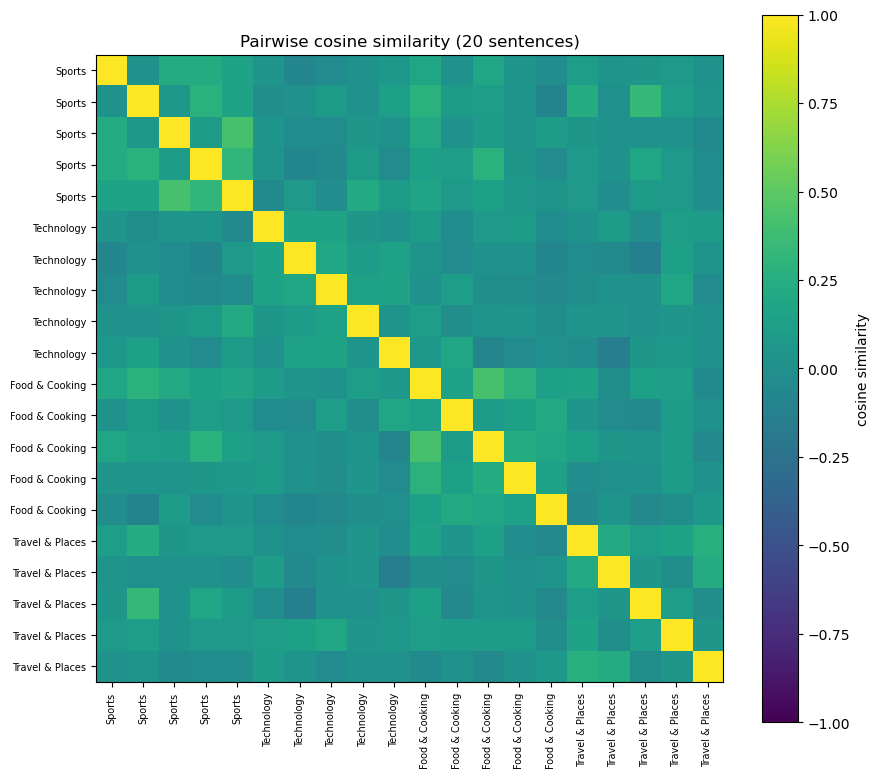

In [4]:
from src.similarity import compute_similarity_matrix
import matplotlib.pyplot as plt
import numpy as np

sim_matrix = compute_similarity_matrix(embeddings)

fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(sim_matrix, cmap="viridis", vmin=-1, vmax=1)
ax.set_xticks(range(len(sentences)))
ax.set_yticks(range(len(sentences)))
ax.set_xticklabels(topics, rotation=90, fontsize=7)
ax.set_yticklabels(topics, fontsize=7)
ax.set_title("Pairwise cosine similarity (20 sentences)")
fig.colorbar(im, label="cosine similarity")
fig.tight_layout()
plt.show()


### Find the best match for a query

Encode a new sentence that was never in the original 20, and find which
of the 20 it's most similar to.

In [5]:
from src.similarity import find_best_match, top_k_matches

queries = [
    "The chef added fresh herbs to the pasta.",           # expect: Food & Cooking
    "The team celebrated their victory on the field.",     # expect: Sports
    "Engineers deployed the new app update to all users.", # expect: Technology
    "We wandered through the old city as the sun set.",    # expect: Travel & Places
]

for query in queries:
    query_embedding = encode_sentences([query])[0]
    best_sentence, score, index = find_best_match(query_embedding, embeddings, sentences)
    print(f"QUERY: {query}")
    print(f"  BEST MATCH ({topics[index]}, score={score:.3f}): {best_sentence}")
    print()


QUERY: The chef added fresh herbs to the pasta.
  BEST MATCH (Food & Cooking, score=0.613): The recipe calls for fresh basil, garlic, and olive oil.

QUERY: The team celebrated their victory on the field.
  BEST MATCH (Sports, score=0.471): The home team won the championship after a tense overtime.

QUERY: Engineers deployed the new app update to all users.
  BEST MATCH (Technology, score=0.372): A software update fixed the security vulnerability overnight.

QUERY: We wandered through the old city as the sun set.
  BEST MATCH (Travel & Places, score=0.510): Tourists gathered at sunset to watch the view from the old fort.



### Top-3 matches for one query

Seeing more than just the top-1 result helps confirm the ranking makes
sense, not just the single winner.

In [6]:
query = "The chef added fresh herbs to the pasta."
query_embedding = encode_sentences([query])[0]

for rank, (sentence, score) in enumerate(top_k_matches(query_embedding, embeddings, sentences, k=3), start=1):
    print(f"{rank}. ({score:.3f}) {sentence}")


1. (0.613) The recipe calls for fresh basil, garlic, and olive oil.
2. (0.432) She simmered the tomato sauce for hours to deepen the flavor.
3. (0.308) He seasoned the steak generously before searing it in the pan.


## t-SNE visualization, grouped by topic

### Do meaningful clusters form?
Reduce the 384-dimensional embeddings to 2D and plot them, colored by
topic. If SBERT is capturing meaning well, sentences from the same topic
should visually cluster together even though the model was never told
what the topics are — the topic labels are only used here for coloring
the plot, not for the encoding itself.

In [7]:
from src.visualize import reduce_to_2d, plot_embeddings

coords_2d = reduce_to_2d(embeddings)
print("2D coordinates shape:", coords_2d.shape)


2D coordinates shape: (20, 2)


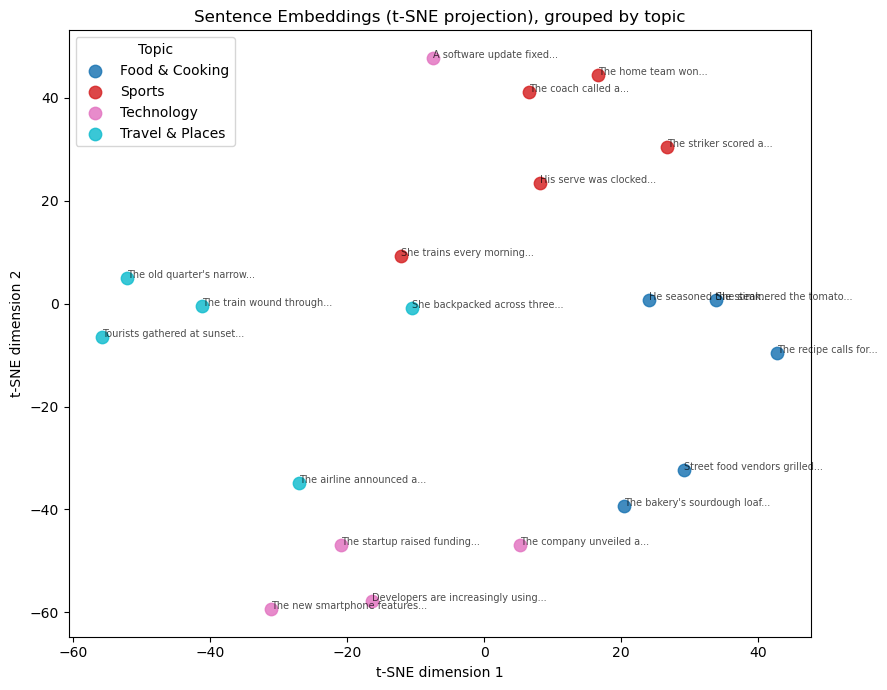

Saved to outputs/tsne_plot.png


In [8]:
fig = plot_embeddings(
    coords_2d,
    topics,
    sentences=sentences,
    save_path="../outputs/tsne_plot.png",  # saved as a downloadable PNG
)
plt.show()
print("Saved to outputs/tsne_plot.png")
